# Car Crash Severity Classification Project

This notebook covers EDA, Data Preparation, and evaluating 5 classification models (KNN, Decision Trees, Random Forests, Logistic Regression, Naive Bayes)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. EDA and Data Preparation

In [2]:
train = pd.read_csv('car_crash_train.csv')
test = pd.read_csv('car_crash_test.csv')

train.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   str    
 3   Seatbelt Used              4000 non-null   str    
 4   Weather Conditions         4000 non-null   str    
 5   Road Conditions            4000 non-null   str    
 6   Crash Type                 4000 non-null   str    
 7   Vehicle Type               4000 non-null   str    
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   str    
 10  Tire Condition             4000 non-null   str    
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float64
 14  Dis

In [4]:
train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Crash Speed (km/h),4000.0,110.999750,52.227839,20.000000,66.00000,112.000000,157.000000,199.000000
Impact Angle (degrees),4000.0,89.979750,51.301514,0.000000,45.00000,89.500000,134.000000,179.000000
Vehicle Age (years),4000.0,9.445500,5.718147,0.000000,5.00000,9.000000,14.000000,19.000000
Driver Age,4000.0,48.698750,17.815972,18.000000,34.00000,49.000000,64.000000,79.000000
Driver Experience (years),4000.0,24.723000,14.211818,0.000000,13.00000,25.000000,37.000000,49.000000
Alcohol Level (BAC%),4000.0,0.101216,0.057820,0.000054,0.05063,0.101574,0.151783,0.199936
Visibility Distance (m),4000.0,247.583500,143.478155,10.000000,120.00000,244.000000,372.000000,499.000000


In [5]:
print("Missing values in train data:")
print(train.isnull().sum())

Missing values in train data:
Crash Speed (km/h)              0
Impact Angle (degrees)          0
Airbag Deployed                 0
Seatbelt Used                   0
Weather Conditions              0
Road Conditions                 0
Crash Type                      0
Vehicle Type                    0
Vehicle Age (years)             0
Brake Condition                 0
Tire Condition                  0
Driver Age                      0
Driver Experience (years)       0
Alcohol Level (BAC%)            0
Distraction Level            2360
Time of Day                     0
Traffic Density                 0
Visibility Distance (m)         0
Severity                        0
dtype: int64


In [6]:
# Target Distribution
train['Severity'].value_counts()

Severity
Minor Injury     2756
Severe Injury    1038
Fatal             206
Name: count, dtype: int64

In [7]:
test.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,68,61,No,Yes,Rain,Uneven,Rear-end,Truck,5,Worn out,Good,75,17,0.090047,NaN,Night,Low,111,Minor Injury
1,143,13,Yes,Yes,Clear,Dry,Rear-end,Truck,1,Good,Good,41,32,0.000211,Other,Afternoon,Medium,326,Minor Injury
2,147,147,Yes,Yes,Snow,Dry,Rear-end,Sedan,8,Good,Good,21,32,0.060945,NaN,Afternoon,High,462,Minor Injury
3,176,35,Yes,Yes,Fog,Wet,Side impact,Motorcycle,6,Good,Good,49,33,0.156030,NaN,Afternoon,High,399,Severe Injury
4,165,94,Yes,Yes,Rain,Dry,Rear-end,SUV,9,Good,Good,41,38,0.112295,NaN,Morning,Medium,395,Minor Injury


In [8]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         1000 non-null   int64  
 1   Impact Angle (degrees)     1000 non-null   int64  
 2   Airbag Deployed            1000 non-null   str    
 3   Seatbelt Used              1000 non-null   str    
 4   Weather Conditions         1000 non-null   str    
 5   Road Conditions            1000 non-null   str    
 6   Crash Type                 1000 non-null   str    
 7   Vehicle Type               1000 non-null   str    
 8   Vehicle Age (years)        1000 non-null   int64  
 9   Brake Condition            1000 non-null   str    
 10  Tire Condition             1000 non-null   str    
 11  Driver Age                 1000 non-null   int64  
 12  Driver Experience (years)  1000 non-null   int64  
 13  Alcohol Level (BAC%)       1000 non-null   float64
 14  Dist

In [9]:
test.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Crash Speed (km/h),1000.0,110.007000,52.362934,20.00000,64.000000,110.000000,156.250000,199.000000
Impact Angle (degrees),1000.0,88.933000,52.540108,0.00000,42.750000,91.000000,135.250000,179.000000
Vehicle Age (years),1000.0,9.854000,5.858413,0.00000,5.000000,10.000000,15.000000,19.000000
Driver Age,1000.0,49.170000,17.672051,18.00000,34.000000,49.000000,64.000000,79.000000
Driver Experience (years),1000.0,23.959000,14.171526,0.00000,12.000000,23.000000,36.000000,49.000000
Alcohol Level (BAC%),1000.0,0.098933,0.058288,0.00001,0.049112,0.094952,0.150219,0.199979
Visibility Distance (m),1000.0,259.001000,141.470488,10.00000,139.500000,259.000000,381.250000,499.000000


In [10]:
print("Missing values in train data:")
print(test.isnull().sum())

Missing values in train data:
Crash Speed (km/h)             0
Impact Angle (degrees)         0
Airbag Deployed                0
Seatbelt Used                  0
Weather Conditions             0
Road Conditions                0
Crash Type                     0
Vehicle Type                   0
Vehicle Age (years)            0
Brake Condition                0
Tire Condition                 0
Driver Age                     0
Driver Experience (years)      0
Alcohol Level (BAC%)           0
Distraction Level            603
Time of Day                    0
Traffic Density                0
Visibility Distance (m)        0
Severity                       0
dtype: int64


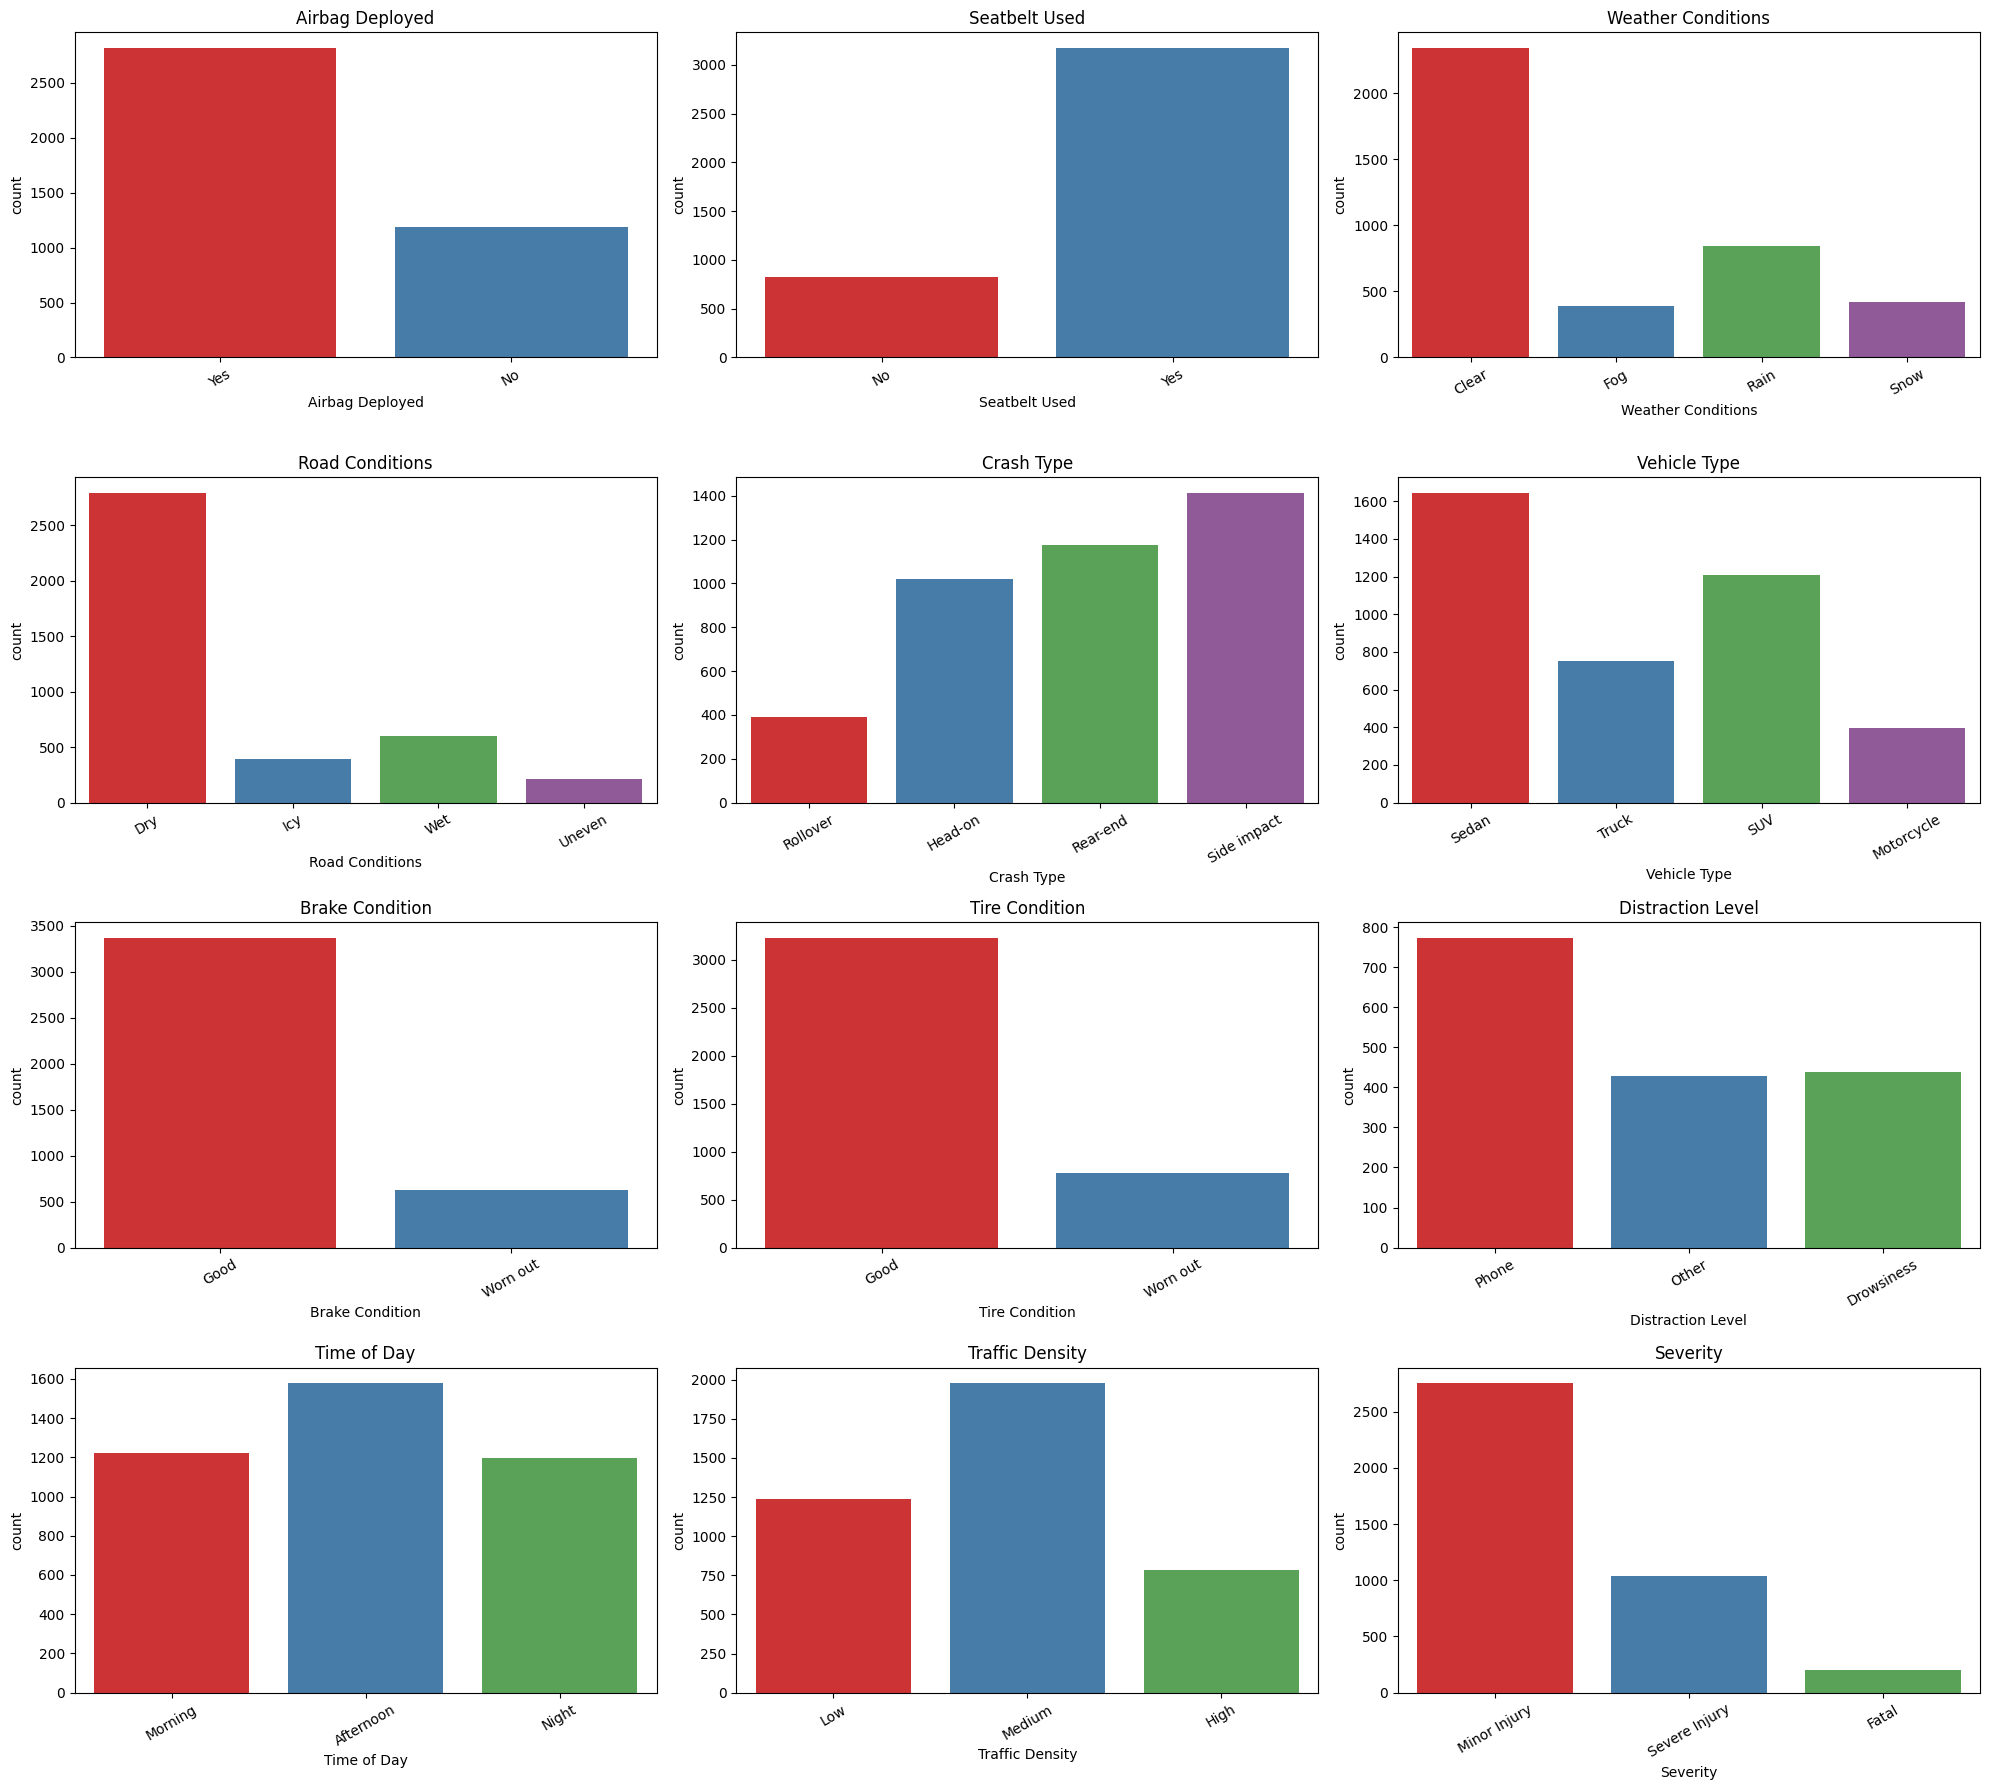

In [11]:
#categorical features distribution
cat_cols = train.select_dtypes(include='object').columns

fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=train, ax=axes[i], palette='Set1')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

if len(cat_cols) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


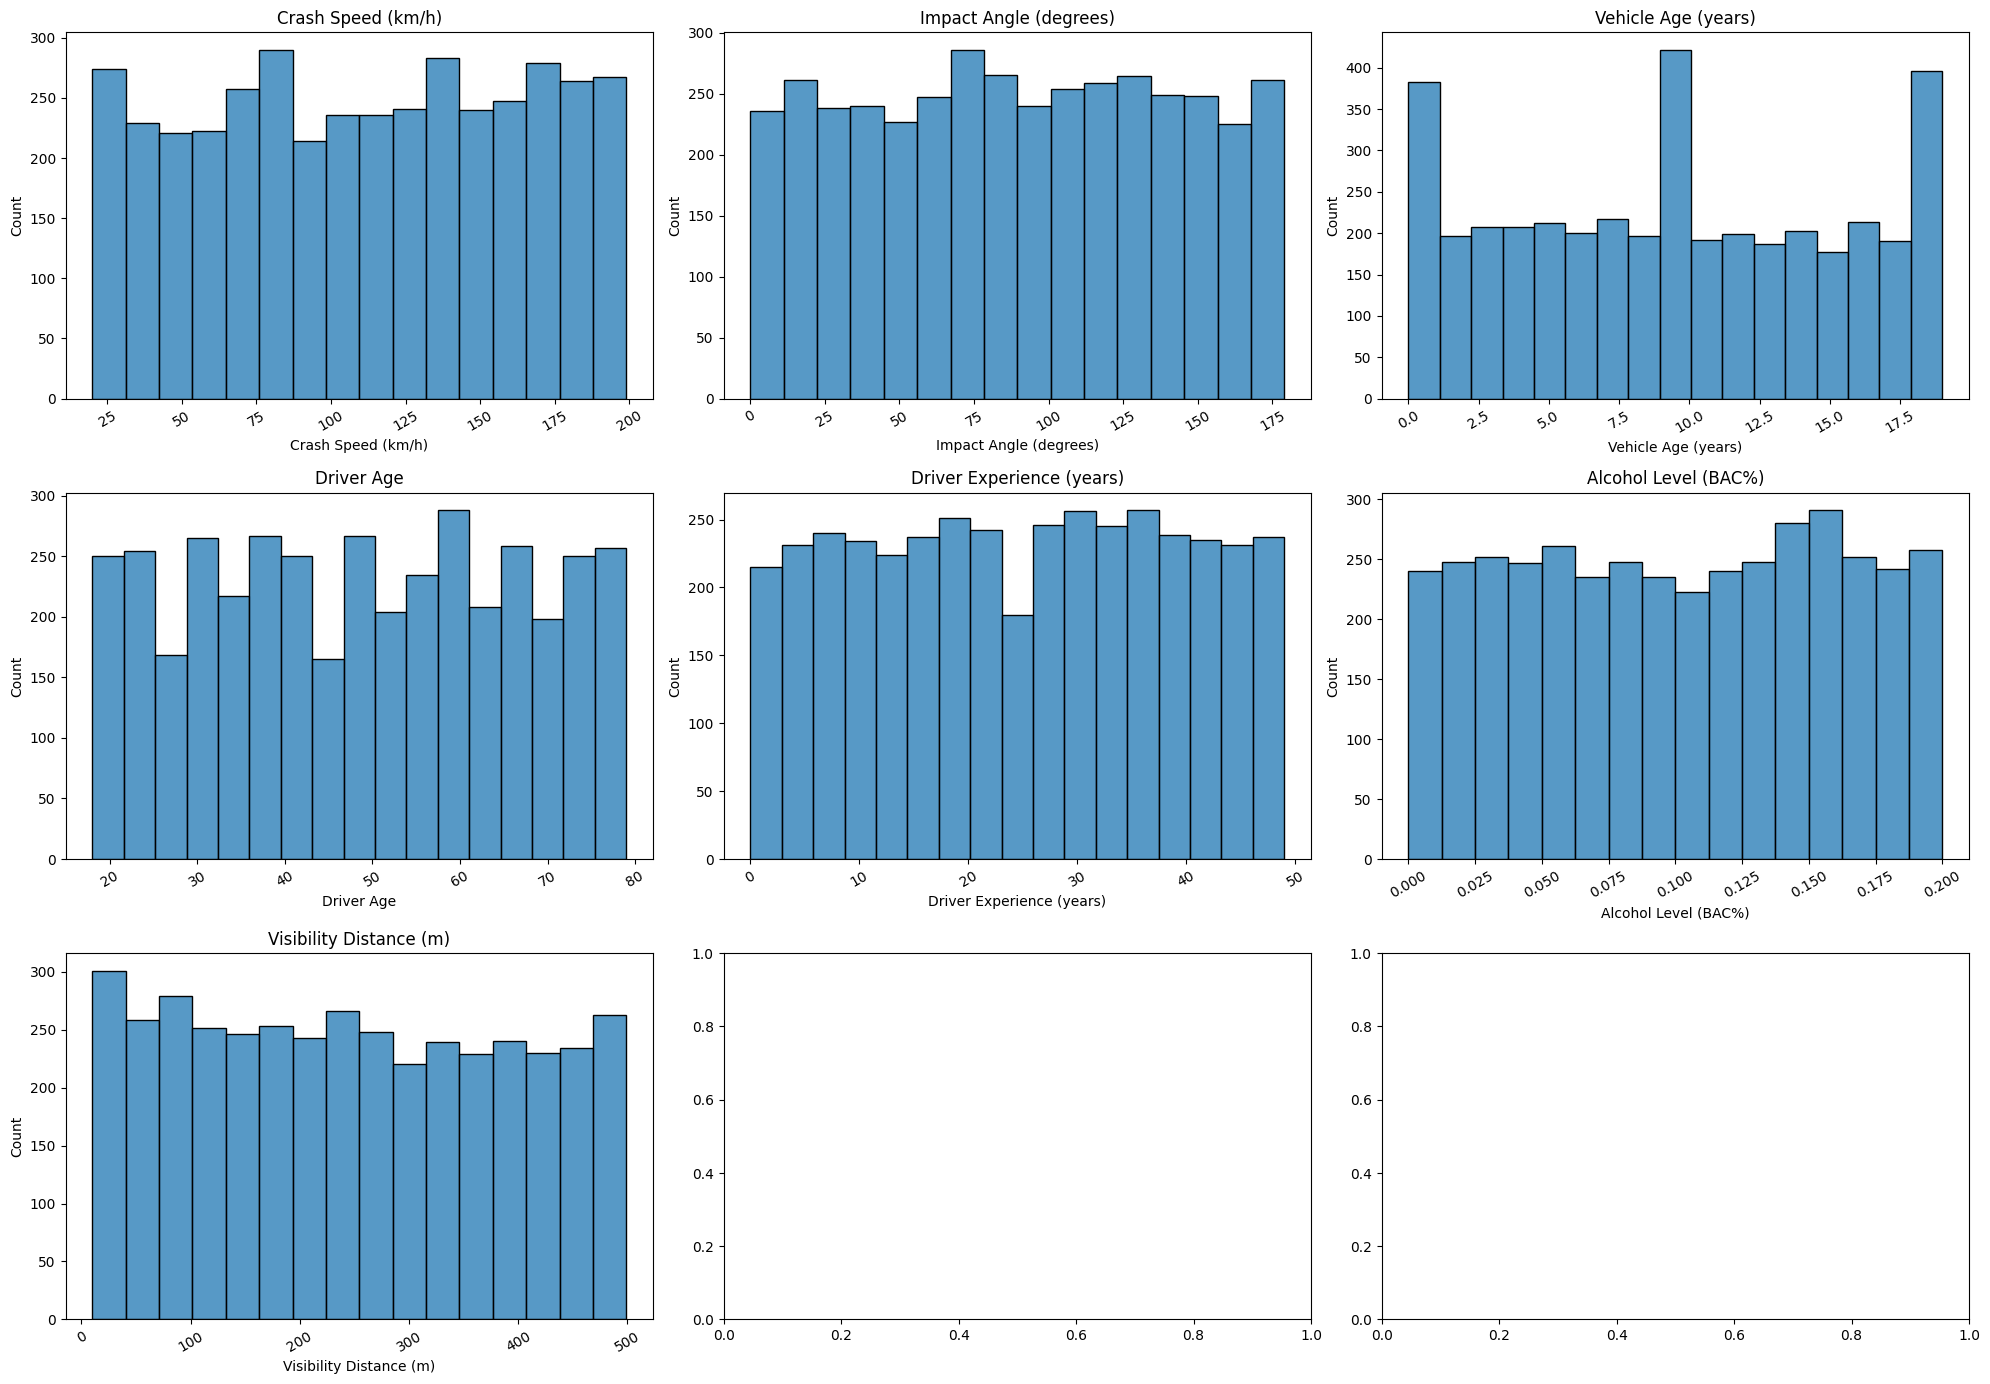

In [12]:
# numerical features distribution
num_cols = train.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(x=col, data=train, ax=axes[i], palette='Set1')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

if len(num_cols) < len(axes):
    axes[-1].set_visible(False)
    axes[-2].set_visible(False)
    axes[-3].set_visible(False)

plt.tight_layout()
plt.show()


### Preprocessing Pipeline

In [13]:
# Imports for preprocessing
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from imblearn.over_sampling import SMOTE

# Feature Engineering before splitting
train['Risk Score'] = train['Crash Speed (km/h)'] * train['Alcohol Level (BAC%)']
train['Experience Ratio'] = train['Driver Experience (years)'] / (train['Driver Age'] + 1)
test['Risk Score'] = test['Crash Speed (km/h)'] * test['Alcohol Level (BAC%)']
test['Experience Ratio'] = test['Driver Experience (years)'] / (test['Driver Age'] + 1)

# Separate Target
X = train.drop('Severity', axis=1)
y = train['Severity']

# Encode Target
le_target = LabelEncoder()
y = le_target.fit_transform(y)

# Train Test Split (Stratified to maintain class proportions)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101, stratify=y)

# Define feature groups
num_cols = ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Visibility Distance (m)', 'Risk Score', 'Experience Ratio']
ordinal_cols = ['Brake Condition', 'Tire Condition']
categorical_cols = ['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Distraction Level', 'Time of Day', 'Traffic Density']

# Preprocessing for numerical data
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for ordinal data
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['Worn out', 'Good'], ['Worn out', 'Good']]))
])

# Preprocessing for categorical data
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

# Bundle preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('ord', ordinal_transformer, ordinal_cols),
        ('cat', cat_transformer, categorical_cols)
    ])

# Preprocess training and test data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
test_preprocessed = preprocessor.transform(test)

# Handle Class Imbalance using SMOTE (Only on training data!)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_preprocessed, y_train)

# Store label names for readable reports
class_names = le_target.classes_.tolist()

# Reassign so downstream code works without modification
X_train = X_train_resampled
y_train = y_train_resampled
# Keep validation split (from train CSV) separate from actual test CSV
X_val = X_test_preprocessed
y_val = y_test
# Actual unseen test set (car_crash_test.csv)
X_test_actual = test_preprocessed
y_test_actual = le_target.transform(test['Severity'])
X_test = X_val   # alias so all model cells below still work unchanged


## 2. K-Nearest Neighbors (KNN)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Start with K=1
knn_model = KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("accuracy", acc)
print("precision", prec)
print("recall", rec)
print("F1 Score:", f1)

accuracy 0.42333333333333334
precision 0.5499879066929909
recall 0.42333333333333334
F1 Score: 0.4668259884592133


In [15]:
cm_knn_init = confusion_matrix(y_test, y_pred)
import pandas as pd
pd.DataFrame(cm_knn_init, index=class_names, columns=class_names)

,Fatal,Minor Injury,Severe Injury
Fatal,11,34,17
Minor Injury,142,384,301
Severe Injury,64,134,113


In [16]:
confusion_matrix(y_test, y_pred)

array([[ 11,  34,  17],
       [142, 384, 301],
       [ 64, 134, 113]])

In [17]:
print(classification_report(y_test, y_pred, target_names=class_names))

               precision    recall  f1-score   support

        Fatal       0.05      0.18      0.08        62
 Minor Injury       0.70      0.46      0.56       827
Severe Injury       0.26      0.36      0.30       311

     accuracy                           0.42      1200
    macro avg       0.34      0.34      0.31      1200
 weighted avg       0.55      0.42      0.47      1200



Best K = 2


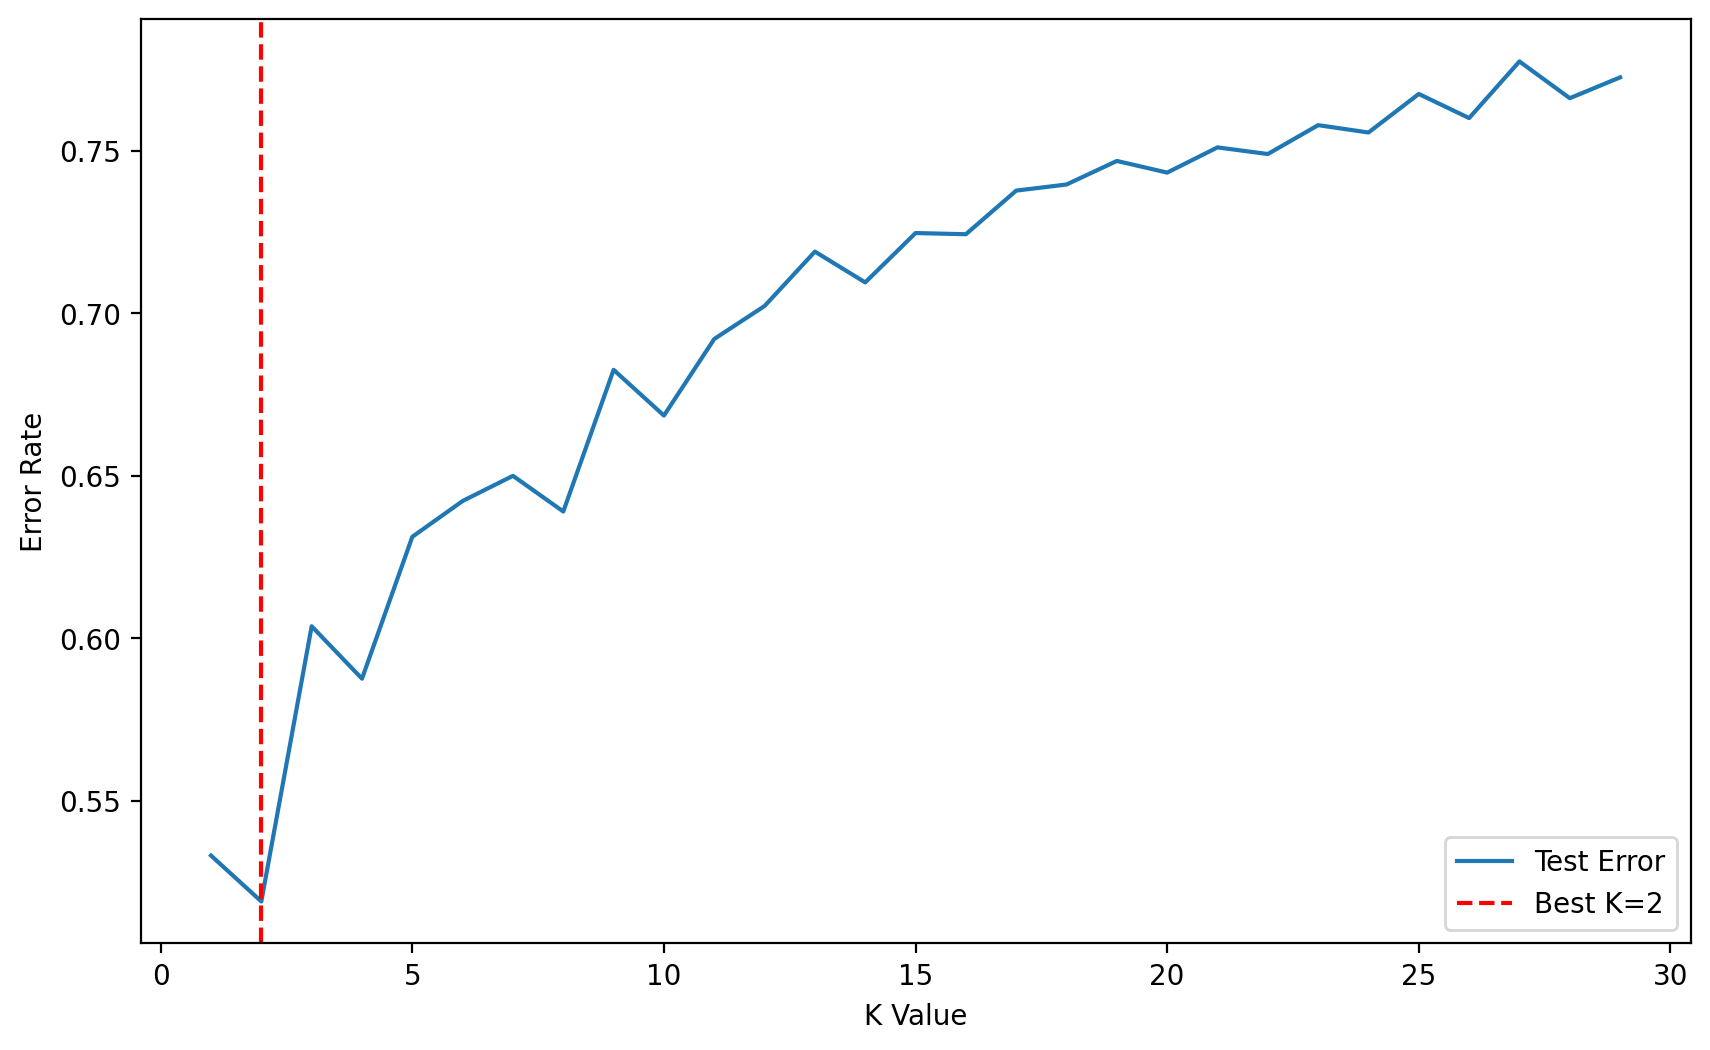

In [18]:
test_error_rates = []

for k in range(1, 30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    y_pred_test = knn_model.predict(X_test)
    test_error = 1 - f1_score(y_test, y_pred_test, average='weighted')
    test_error_rates.append(test_error)
    
best_k = np.argmin(test_error_rates) + 1
print(f"Best K = {best_k}")

plt.figure(figsize=(10,6), dpi=200)
plt.plot(range(1, 30), test_error_rates, label='Test Error')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel("K Value")
plt.show()

In [19]:
knn_best = KNeighborsClassifier(n_neighbors=2) 
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

print(classification_report(y_test, y_pred, target_names=class_names))
confusion_matrix(y_test, y_pred)

               precision    recall  f1-score   support

        Fatal       0.05      0.24      0.08        62
 Minor Injury       0.72      0.50      0.59       827
Severe Injury       0.28      0.27      0.28       311

     accuracy                           0.42      1200
    macro avg       0.35      0.34      0.31      1200
 weighted avg       0.57      0.42      0.48      1200



array([[ 15,  32,  15],
       [217, 411, 199],
       [100, 127,  84]])

## 3. Decision Trees

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import plot_tree

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
base_pred = dt_model.predict(X_test)

confusion_matrix(y_test, base_pred)

array([[  2,  45,  15],
       [ 66, 523, 238],
       [ 22, 184, 105]])

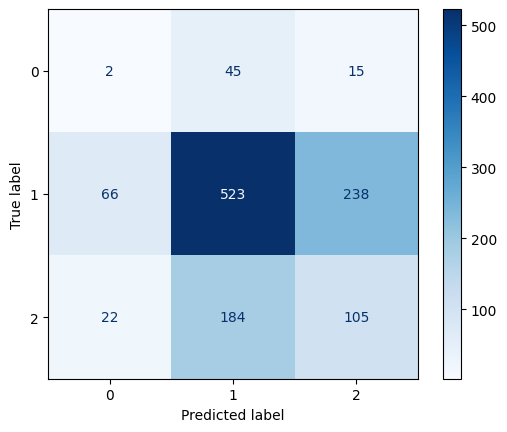

In [21]:
ConfusionMatrixDisplay.from_estimator(dt_model, X_test, y_test, cmap="Blues")
plt.show()

In [22]:
print(classification_report(y_test, base_pred, target_names=class_names))

               precision    recall  f1-score   support

        Fatal       0.02      0.03      0.03        62
 Minor Injury       0.70      0.63      0.66       827
Severe Injury       0.29      0.34      0.31       311

     accuracy                           0.53      1200
    macro avg       0.34      0.33      0.33      1200
 weighted avg       0.56      0.53      0.54      1200



               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        62
 Minor Injury       0.69      1.00      0.82       827
Severe Injury       0.00      0.00      0.00       311

     accuracy                           0.69      1200
    macro avg       0.23      0.33      0.27      1200
 weighted avg       0.47      0.69      0.56      1200





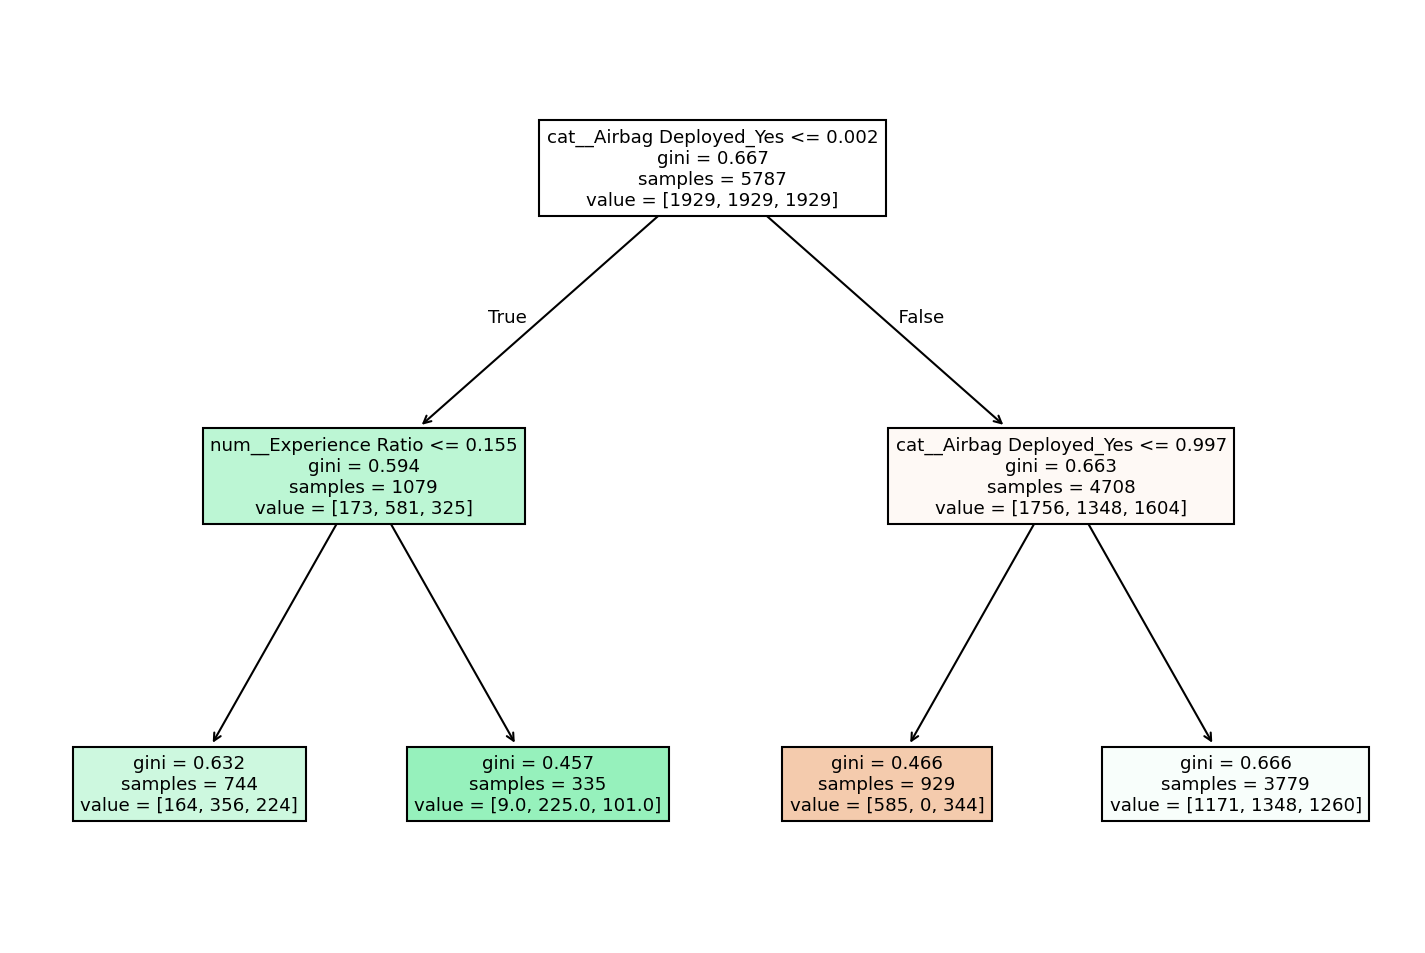

In [23]:
def report_dt_model(model):
    dt_model_preds = model.predict(X_test)
    print(classification_report(y_test, dt_model_preds, target_names=class_names))
    print('\n')
    plt.figure(figsize=(12,8),dpi=150)
    plot_tree(model,filled=True,feature_names=preprocessor.get_feature_names_out());
    
pruned_tree = DecisionTreeClassifier(max_depth=2)
pruned_tree.fit(X_train, y_train)
report_dt_model(pruned_tree)

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        62
 Minor Injury       0.69      1.00      0.82       827
Severe Injury       0.00      0.00      0.00       311

     accuracy                           0.69      1200
    macro avg       0.23      0.33      0.27      1200
 weighted avg       0.47      0.69      0.56      1200





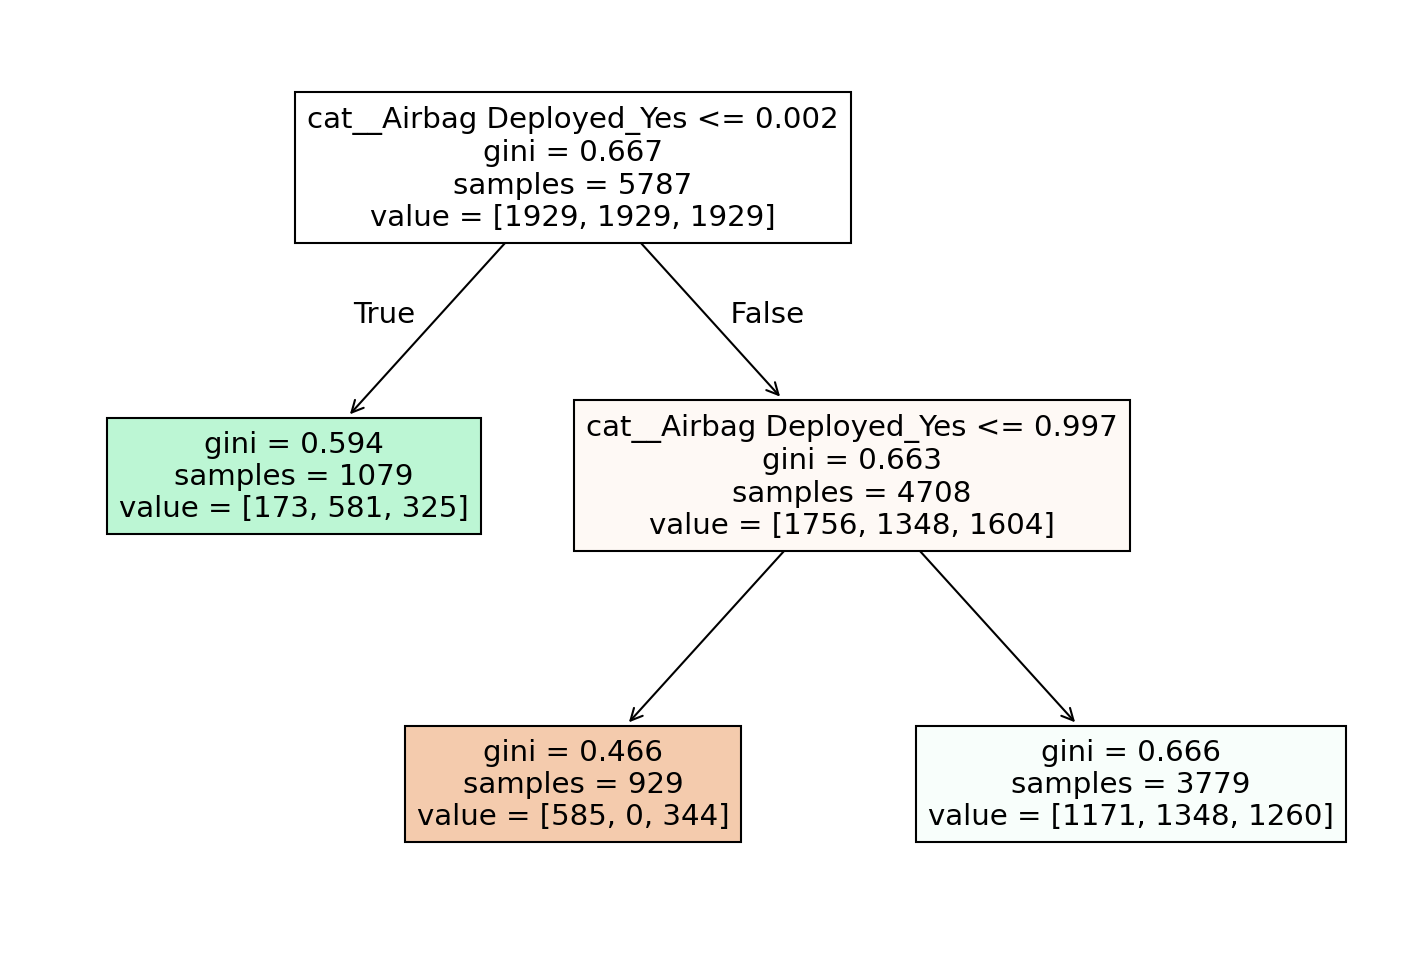

In [24]:
pruned_tree = DecisionTreeClassifier(max_leaf_nodes=3)
pruned_tree.fit(X_train,y_train)
report_dt_model(pruned_tree)

In [25]:
entropy_tree = DecisionTreeClassifier(criterion='entropy')
entropy_tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

## 4. Random Forests

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
preds = rf_model.predict(X_test)

confusion_matrix(y_test, preds)

array([[  0,  61,   1],
       [  3, 804,  20],
       [  1, 297,  13]])

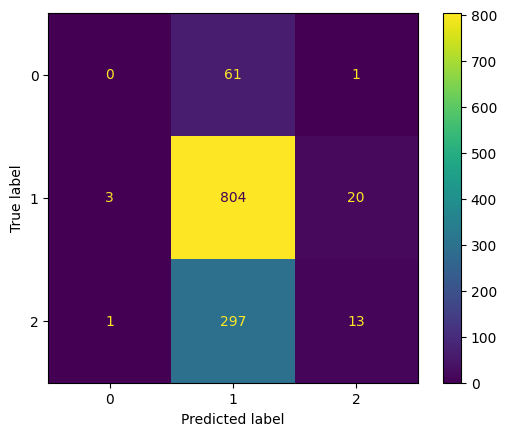

In [27]:
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.show()

In [28]:
print(classification_report(y_test, preds, target_names=class_names))

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        62
 Minor Injury       0.69      0.97      0.81       827
Severe Injury       0.38      0.04      0.08       311

     accuracy                           0.68      1200
    macro avg       0.36      0.34      0.29      1200
 weighted avg       0.58      0.68      0.58      1200



## 5. Logistic Regression

In [29]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import ConfusionMatrixDisplay

log_model = LogisticRegression()
log_model.fit(scaled_X_train,y_train)

y_pred = log_model.predict(scaled_X_test)
accuracy_score(y_test, y_pred)

0.30833333333333335

In [31]:
confusion_matrix(y_test, y_pred)

array([[ 21,  25,  16],
       [283, 254, 290],
       [118,  98,  95]])

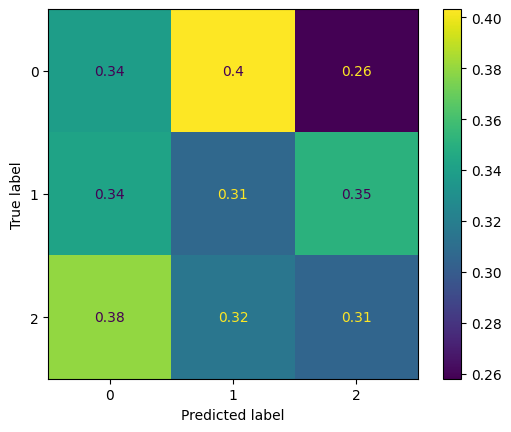

In [32]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true')
plt.show()

In [33]:
print(classification_report(y_test, y_pred, target_names=class_names))

               precision    recall  f1-score   support

        Fatal       0.05      0.34      0.09        62
 Minor Injury       0.67      0.31      0.42       827
Severe Injury       0.24      0.31      0.27       311

     accuracy                           0.31      1200
    macro avg       0.32      0.32      0.26      1200
 weighted avg       0.53      0.31      0.36      1200



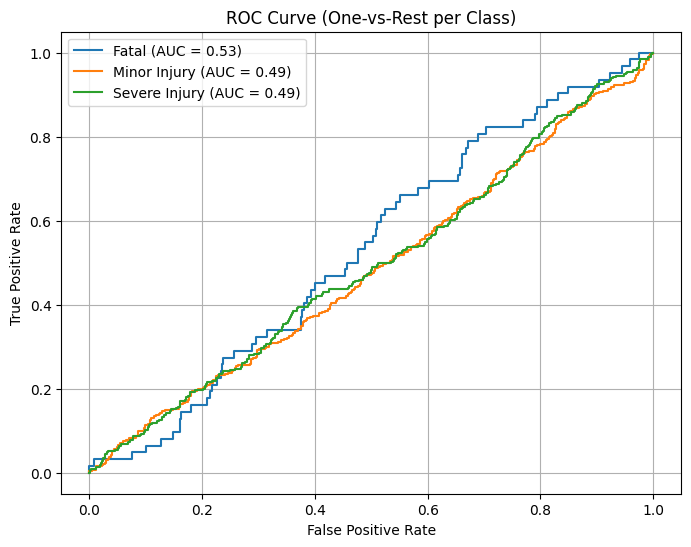

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

y_prob_all = log_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_prob_all[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_prob_all[:, i])
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {auc:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest per Class)")
plt.legend()
plt.grid()
plt.show()


In [35]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_prob_all = log_model.predict_proba(X_test)

for i, class_name in enumerate(class_names):
    auc = roc_auc_score(y_test_bin[:, i], y_prob_all[:, i])
    print(f"{class_name}: AUC = {auc:.4f}")


Fatal: AUC = 0.5311
Minor Injury: AUC = 0.4850
Severe Injury: AUC = 0.4925


In [36]:
roc_auc_score(y_test, log_model.predict_proba(X_test), multi_class='ovr', average='macro')


0.5028684223713461

In [37]:
fpr, tpr, thresholds

(array([0.        , 0.00112486, 0.00112486, 0.00337458, 0.00337458,
        0.01124859, 0.01124859, 0.01799775, 0.01799775, 0.02024747,
        0.02024747, 0.02137233, 0.02137233, 0.02362205, 0.02362205,
        0.02474691, 0.02474691, 0.02699663, 0.02699663, 0.02812148,
        0.02812148, 0.0303712 , 0.0303712 , 0.03374578, 0.03374578,
        0.04611924, 0.04611924, 0.05061867, 0.05061867, 0.05174353,
        0.05174353, 0.05624297, 0.05624297, 0.06749156, 0.06749156,
        0.071991  , 0.071991  , 0.07649044, 0.07649044, 0.08998875,
        0.08998875, 0.09111361, 0.09111361, 0.09673791, 0.09673791,
        0.09898763, 0.09898763, 0.10461192, 0.10461192, 0.10573678,
        0.10573678, 0.10686164, 0.10686164, 0.11023622, 0.11023622,
        0.12035996, 0.12035996, 0.12260967, 0.12260967, 0.12823397,
        0.12823397, 0.12935883, 0.12935883, 0.13160855, 0.13160855,
        0.13273341, 0.13273341, 0.13498313, 0.13498313, 0.14285714,
        0.14285714, 0.143982  , 0.143982  , 0.15

## 6. Naive Bayes

In [38]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=class_names))

               precision    recall  f1-score   support

        Fatal       0.04      0.19      0.06        62
 Minor Injury       0.67      0.43      0.52       827
Severe Injury       0.24      0.28      0.26       311

     accuracy                           0.38      1200
    macro avg       0.31      0.30      0.28      1200
 weighted avg       0.52      0.38      0.43      1200



In [39]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 12,  31,  19],
       [216, 353, 258],
       [ 81, 144,  86]])

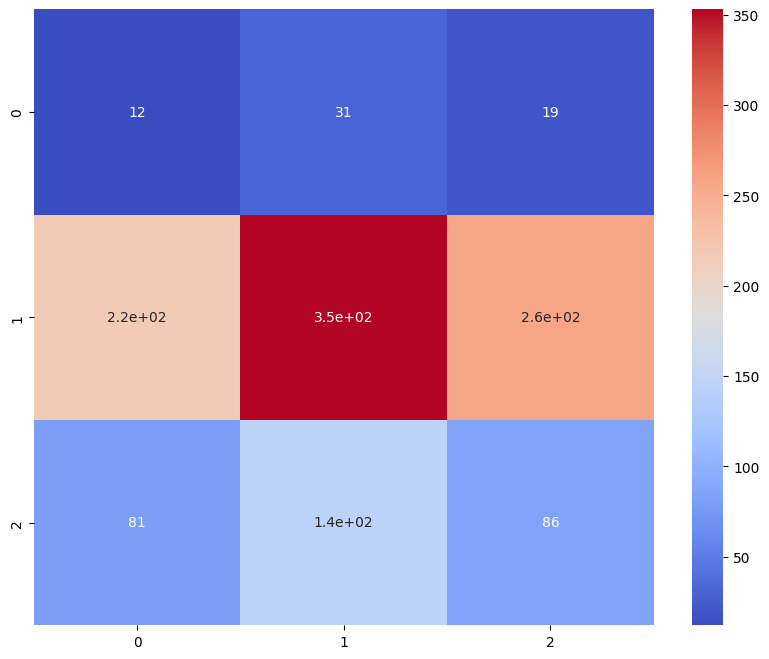

In [40]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.show()

## 7. Model Comparison (Train vs Test)

,Model,Train Accuracy,Train F1,Val Accuracy (split),Val F1 (split),Test Accuracy (car_crash_test),Test F1 (car_crash_test)
0,KNN,0.933299,0.933018,0.425000,0.480936,0.415,0.470219
1,Decision Tree (Base),1.000000,1.000000,0.525000,0.539247,0.524,0.539234
2,Decision Tree (Pruned),0.434422,0.325939,0.689167,0.562349,0.710,0.589591
3,Random Forest,1.000000,1.000000,0.680833,0.576686,0.689,0.587821
4,Logistic Regression,0.362018,0.287051,0.293333,0.244071,0.300,0.256970
5,Naive Bayes,0.493174,0.485657,0.375833,0.428559,0.391,0.450657


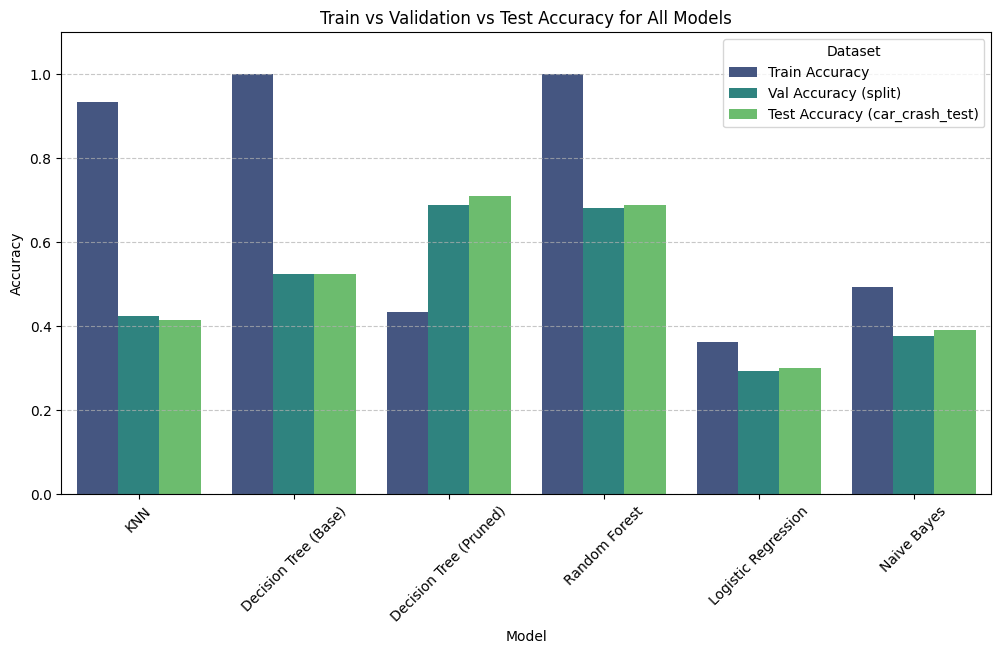

In [41]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary of trained models
models = {
    'KNN': knn_best,
    'Decision Tree (Base)': dt_model,
    'Decision Tree (Pruned)': pruned_tree,
    'Random Forest': rf_model,
    'Logistic Regression': log_model,
    'Naive Bayes': nb_model
}

results = []

for name, m in models.items():
    # Predict on Train (SMOTE-resampled)
    y_train_pred = m.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')

    # Predict on Validation split (held-out 30% of train CSV)
    y_val_pred = m.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    # Predict on Actual Test CSV (car_crash_test.csv)
    y_actual_pred = m.predict(X_test_actual)
    actual_acc = accuracy_score(y_test_actual, y_actual_pred)
    actual_f1 = f1_score(y_test_actual, y_actual_pred, average='weighted')

    results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Train F1': train_f1,
        'Val Accuracy (split)': val_acc,
        'Val F1 (split)': val_f1,
        'Test Accuracy (car_crash_test)': actual_acc,
        'Test F1 (car_crash_test)': actual_f1,
    })

results_df = pd.DataFrame(results)
display(results_df)

# Plotting the comparison (Accuracy)
results_df_melted = results_df.melt(id_vars='Model',
    value_vars=['Train Accuracy', 'Val Accuracy (split)', 'Test Accuracy (car_crash_test)'],
    var_name='Dataset', value_name='Accuracy')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', hue='Dataset', data=results_df_melted, palette='viridis')
plt.title('Train vs Validation vs Test Accuracy for All Models')
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
